# BÀI TẬP BUỔI 11 — ENSEMBLE LEARNING
## Dự đoán `Transported` trên Spaceship Titanic

**Sinh viên thực hiện:** Nguyễn Tiến Đạt (2410712)

## 0. Import thư viện

In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    cross_val_predict,
    train_test_split
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
N_SPLITS = 5

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

print("Thiết lập hoàn tất.")

Thiết lập hoàn tất.


## 1. Đọc dữ liệu

In [2]:
def find_dataset_dir():
    candidate_dirs = [
        Path("."),
        Path("./data"),
        Path("/kaggle/input/spaceship-titanic"),
        Path("/mnt/data"),
    ]

    for directory in candidate_dirs:
        train_path = directory / "train.csv"
        test_path = directory / "test.csv"

        if train_path.exists() and test_path.exists():
            return directory

    raise FileNotFoundError(
        "Không tìm thấy train.csv và test.csv. "
        "Hãy đặt hai file trong cùng thư mục với notebook, thư mục data/, "
        "hoặc cập nhật danh sách candidate_dirs."
    )


DATA_DIR = find_dataset_dir()

train_raw = pd.read_csv(DATA_DIR / "train.csv")
test_raw = pd.read_csv(DATA_DIR / "test.csv")

sample_submission_path = DATA_DIR / "sample_submission.csv"
sample_submission = (
    pd.read_csv(sample_submission_path)
    if sample_submission_path.exists()
    else None
)

print("DATA_DIR:", DATA_DIR.resolve())
print("Train shape:", train_raw.shape)
print("Test shape :", test_raw.shape)

display(train_raw.head())

DATA_DIR: D:\MyWorkspace\Others\mliot\mliot-pyml-2026-hw\week06\Homework_11
Train shape: (8693, 14)
Test shape : (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0000,False,0.0000,0.0000,0.0000,0.0000,0.0000,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0000,False,109.0000,9.0000,25.0000,549.0000,44.0000,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0000,True,43.0000,"3,576.0000",0.0000,"6,715.0000",49.0000,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0000,False,0.0000,"1,283.0000",371.0000,"3,329.0000",193.0000,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0000,False,303.0000,70.0000,151.0000,565.0000,2.0000,Willy Santantines,True


## 2. Tổng quan dữ liệu

In [3]:
print("Thông tin tập train:")
train_raw.info()

print("\nSố dòng trùng hoàn toàn:", train_raw.duplicated().sum())
print("Số PassengerId trùng:", train_raw["PassengerId"].duplicated().sum())

Thông tin tập train:
<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB

Số dòng trùng hoàn toàn: 0
Số PassengerId trùng: 0


In [4]:
missing_summary = (
    pd.DataFrame({
        "missing_count": train_raw.isna().sum(),
        "missing_percent": train_raw.isna().mean() * 100
    })
    .sort_values("missing_percent", ascending=False)
)

display(missing_summary)

,missing_count,missing_percent
CryoSleep,217,2.4963
ShoppingMall,208,2.3927
VIP,203,2.3352
HomePlanet,201,2.3122
Name,200,2.3007
Cabin,199,2.2892
VRDeck,188,2.1627
Spa,183,2.1051
FoodCourt,183,2.1051
Destination,182,2.0936


Mỗi biến đều có missing values nhất định. Điền vào các missing values để xử lý được số liệu trong bước tiếp theo. Trong đó:
- Biến liên tục thì điền median
- Biên phân loại thì điền bằng mode

,count,ratio
Transported,,
True,4378,0.5036
False,4315,0.4964


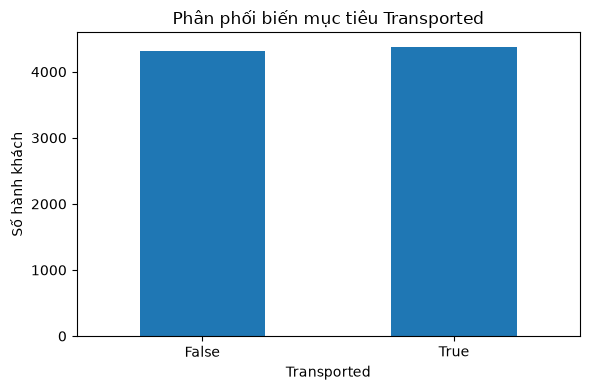

In [5]:
target_counts = train_raw["Transported"].value_counts()
target_ratio = train_raw["Transported"].value_counts(normalize=True)

display(pd.DataFrame({
    "count": target_counts,
    "ratio": target_ratio
}))

ax = target_counts.sort_index().plot(
    kind="bar",
    figsize=(6, 4),
    rot=0,
    title="Phân phối biến mục tiêu Transported"
)
ax.set_xlabel("Transported")
ax.set_ylabel("Số hành khách")
plt.tight_layout()
plt.show()

Hai giá trị True và False cân bằng, nên có thể dùng Accuracy nhưng vẫn sẽ tính cả F1-score và ROC-AUC.

## 3. EDA

,count,median,mean
CryoSleep,,,
False,5439,"1,019.0000","2,248.2997"
True,3037,0.0000,0.0000
NaN,217,703.0000,"1,368.4286"


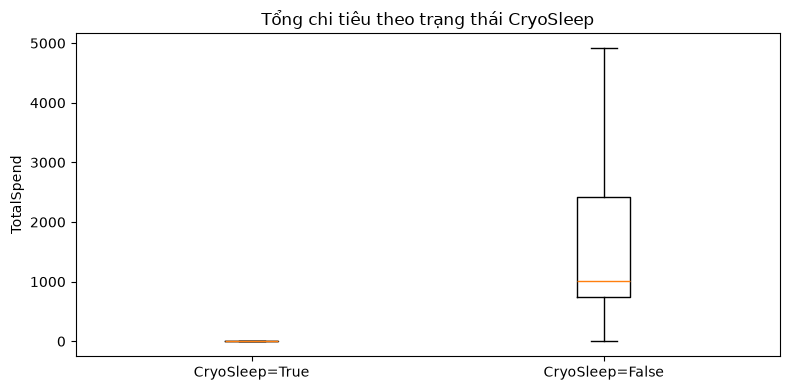

In [6]:
SPENDING_COLS = [
    "RoomService",
    "FoodCourt",
    "ShoppingMall",
    "Spa",
    "VRDeck",
]

eda_df = train_raw.copy()

eda_df["TotalSpend"] = eda_df[SPENDING_COLS].sum(
    axis=1,
    min_count=1
)

spend_by_cryo = (
    eda_df
    .groupby("CryoSleep", dropna=False)["TotalSpend"]
    .agg(["count", "median", "mean"])
)

display(spend_by_cryo)

plot_data = [
    eda_df.loc[
        eda_df["CryoSleep"] == True,
        "TotalSpend"
    ].dropna(),

    eda_df.loc[
        eda_df["CryoSleep"] == False,
        "TotalSpend"
    ].dropna(),
]

fig, ax = plt.subplots(figsize=(8, 4))

ax.boxplot(
    plot_data,
    tick_labels=[
        "CryoSleep=True",
        "CryoSleep=False"
    ],
    showfliers=False
)

ax.set_ylabel("TotalSpend")
ax.set_title("Tổng chi tiêu theo trạng thái CryoSleep")

plt.tight_layout()
plt.show()

- Nhóm CryoSleep=True gần như không phát sinh chi tiêu.
- Nhóm CryoSleep=False có mức chi tiêu cao hơn và phân tán lớn hơn.
- CryoSleep có quan hệ rõ với hành vi chi tiêu của hành khách.

,TransportedRate
HomePlanet,
Earth,0.4239
NaN,0.5124
Mars,0.5230
Europa,0.6588


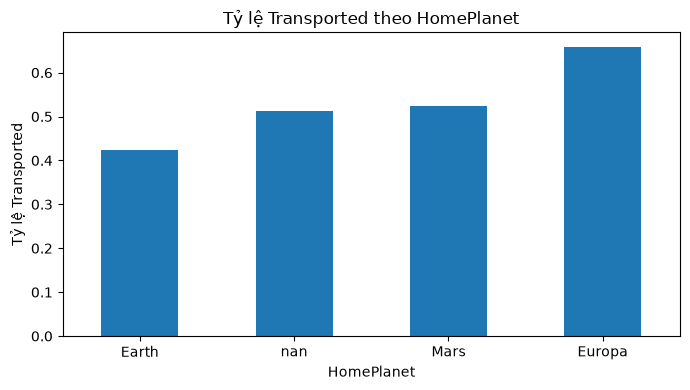

In [7]:
homeplanet_rate = (
    train_raw.groupby("HomePlanet", dropna=False)["Transported"]
    .mean()
    .sort_values()
)

display(homeplanet_rate.to_frame("TransportedRate"))

ax = homeplanet_rate.plot(
    kind="bar",
    figsize=(7, 4),
    rot=0,
    title="Tỷ lệ Transported theo HomePlanet"
)
ax.set_xlabel("HomePlanet")
ax.set_ylabel("Tỷ lệ Transported")
plt.tight_layout()
plt.show()

- Europa có tỷ lệ Transported cao nhất, còn Earth thấp nhất.
- Mars và nhóm thiếu thông tin HomePlanet có tỷ lệ ở mức trung gian.
- HomePlanet là đặc trưng phân loại có khả năng hỗ trợ dự đoán.

In [8]:
group_id = train_raw["PassengerId"].str.split("_").str[0]

group_audit = pd.DataFrame({
    "PassengerId": train_raw["PassengerId"],
    "GroupId": group_id,
    "HomePlanet": train_raw["HomePlanet"],
    "Cabin": train_raw["Cabin"],
})

display(group_audit.head(10))

print("Số nhóm trong train:", group_audit["GroupId"].nunique())
print(
    "Tỷ lệ hành khách thuộc nhóm nhiều hơn một người:",
    (group_audit["GroupId"].map(group_audit["GroupId"].value_counts()) > 1).mean()
)

,PassengerId,GroupId,HomePlanet,Cabin
0,0001_01,0001,Europa,B/0/P
1,0002_01,0002,Earth,F/0/S
2,0003_01,0003,Europa,A/0/S
3,0003_02,0003,Europa,A/0/S
4,0004_01,0004,Earth,F/1/S
5,0005_01,0005,Earth,F/0/P
6,0006_01,0006,Earth,F/2/S
7,0006_02,0006,Earth,G/0/S
8,0007_01,0007,Earth,F/3/S
9,0008_01,0008,Europa,B/1/P


Số nhóm trong train: 6217
Tỷ lệ hành khách thuộc nhóm nhiều hơn một người: 0.4472564132060278



# Bước 2: Feature Engineering

Dựa trên EDA, bài làm xây dựng các đặc trưng mới theo bốn nhóm.

### 1. Nhóm hành khách

- `Group`: mã nhóm lấy từ `PassengerId`.
- `PassengerNo`: số thứ tự của hành khách trong nhóm.
- `GroupSize`: số thành viên có cùng mã nhóm.
- `Solo`: hành khách đi một mình hay theo nhóm.
- `FamilySize`: số người có cùng họ trong cùng nhóm.

### 2. Vị trí cabin

- `CabinDeck`: boong tàu.
- `CabinNum`: số cabin.
- `CabinSide`: mạn tàu.
- `CabinRegion`: vùng cabin được chia theo số phòng.

### 3. Hành vi chi tiêu

- `TotalSpend`: tổng năm khoản chi tiêu.
- `NoSpending`: không phát sinh chi tiêu.
- `ServiceCount`: số loại dịch vụ đã sử dụng.
- `BasicSpend`: RoomService, FoodCourt và ShoppingMall.
- `LuxurySpend`: Spa và VRDeck.
- `SpendingPerService`: chi tiêu trung bình trên mỗi dịch vụ đã sử dụng.
- Các biến `Log_*` để giảm độ lệch phải.

### 4. Độ tuổi

- `AgeGroup`: chia tuổi thành các nhóm có ý nghĩa hành vi.

Train và test được ghép tạm thời để việc tạo đặc trưng đồng nhất. Biến
`Transported` không được dùng trong quá trình này.


In [9]:
y_train = train_raw["Transported"].astype(int)
train_len = len(train_raw)

df_all = pd.concat(
    [
        train_raw.drop(columns="Transported"),
        test_raw
    ],
    axis=0,
    ignore_index=True
)

print("Số mẫu train:", train_len)
print("Tổng số mẫu train + test:", len(df_all))
display(df_all.head())

Số mẫu train: 8693
Tổng số mẫu train + test: 12970


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0000,False,0.0000,0.0000,0.0000,0.0000,0.0000,Maham Ofracculy
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0000,False,109.0000,9.0000,25.0000,549.0000,44.0000,Juanna Vines
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0000,True,43.0000,"3,576.0000",0.0000,"6,715.0000",49.0000,Altark Susent
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0000,False,0.0000,"1,283.0000",371.0000,"3,329.0000",193.0000,Solam Susent
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0000,False,303.0000,70.0000,151.0000,565.0000,2.0000,Willy Santantines



## 2.1. Đặc trưng nhóm và gia đình

`PassengerId` có dạng `gggg_pp`. Phần `gggg` biểu diễn nhóm, còn `pp`
biểu diễn vị trí của hành khách trong nhóm.

Họ của hành khách được kết hợp với mã nhóm để tránh gộp nhầm những người
cùng họ nhưng không đi chung.


In [10]:
passenger_parts = df_all["PassengerId"].str.split("_", expand=True)

df_all["Group"] = passenger_parts[0]
df_all["PassengerNo"] = pd.to_numeric(
    passenger_parts[1],
    errors="coerce"
)

group_size_map = df_all["Group"].value_counts()
df_all["GroupSize"] = df_all["Group"].map(group_size_map)
df_all["Solo"] = (df_all["GroupSize"] == 1).astype(int)

df_all["LastName"] = (
    df_all["Name"]
    .fillna("")
    .str.strip()
    .str.split()
    .str[-1]
    .replace("", np.nan)
)

df_all["FamilyKey"] = np.where(
    df_all["LastName"].notna(),
    df_all["Group"].astype(str) + "_" + df_all["LastName"].astype(str),
    np.nan
)

family_size_map = df_all["FamilyKey"].value_counts(dropna=True)
df_all["FamilySize"] = (
    df_all["FamilyKey"]
    .map(family_size_map)
    .fillna(df_all["GroupSize"])
)

display(
    df_all[
        [
            "PassengerId",
            "Name",
            "Group",
            "PassengerNo",
            "GroupSize",
            "Solo",
            "LastName",
            "FamilySize"
        ]
    ].head(10)
)

,PassengerId,Name,Group,PassengerNo,GroupSize,Solo,LastName,FamilySize
0,0001_01,Maham Ofracculy,0001,1,1,1,Ofracculy,1.0000
1,0002_01,Juanna Vines,0002,1,1,1,Vines,1.0000
2,0003_01,Altark Susent,0003,1,2,0,Susent,2.0000
3,0003_02,Solam Susent,0003,2,2,0,Susent,2.0000
4,0004_01,Willy Santantines,0004,1,1,1,Santantines,1.0000
5,0005_01,Sandie Hinetthews,0005,1,1,1,Hinetthews,1.0000
6,0006_01,Billex Jacostaffey,0006,1,2,0,Jacostaffey,2.0000
7,0006_02,Candra Jacostaffey,0006,2,2,0,Jacostaffey,2.0000
8,0007_01,Andona Beston,0007,1,1,1,Beston,1.0000
9,0008_01,Erraiam Flatic,0008,1,3,0,Flatic,3.0000



## 2.2. Đặc trưng cabin

`Cabin` có cấu trúc `Deck/Number/Side`. Việc phân rã chuỗi giúp mô hình
học riêng ảnh hưởng của boong, số phòng và mạn tàu.

`CabinRegion` được tạo để mô hình nhận biết vị trí tương đối mà không chỉ
dựa vào số cabin liên tục.


In [11]:
cabin_parts = df_all["Cabin"].str.split("/", expand=True)

df_all["CabinDeck"] = cabin_parts[0]
df_all["CabinNum"] = pd.to_numeric(
    cabin_parts[1],
    errors="coerce"
)
df_all["CabinSide"] = cabin_parts[2]

df_all["CabinRegion"] = pd.cut(
    df_all["CabinNum"],
    bins=[-1, 300, 600, 900, 1200, 1500, np.inf],
    labels=["R1", "R2", "R3", "R4", "R5", "R6"]
)

display(
    df_all[
        [
            "Cabin",
            "CabinDeck",
            "CabinNum",
            "CabinSide",
            "CabinRegion"
        ]
    ].head(10)
)

,Cabin,CabinDeck,CabinNum,CabinSide,CabinRegion
0,B/0/P,B,0.0000,P,R1
1,F/0/S,F,0.0000,S,R1
2,A/0/S,A,0.0000,S,R1
3,A/0/S,A,0.0000,S,R1
4,F/1/S,F,1.0000,S,R1
5,F/0/P,F,0.0000,P,R1
6,F/2/S,F,2.0000,S,R1
7,G/0/S,G,0.0000,S,R1
8,F/3/S,F,3.0000,S,R1
9,B/1/P,B,1.0000,P,R1



## 2.3. Đặc trưng chi tiêu và tuổi

Các khoản chi tiêu lệch phải mạnh. Bài làm giữ thông tin tổng hợp và dùng
`log1p` để giảm tác động của các giá trị rất lớn.

`ServiceCount` giúp phân biệt một người chi tiêu tập trung vào một dịch vụ
với một người sử dụng nhiều loại dịch vụ.


In [12]:
SPENDING_COLS = [
    "RoomService",
    "FoodCourt",
    "ShoppingMall",
    "Spa",
    "VRDeck"
]

df_all["TotalSpend"] = df_all[SPENDING_COLS].sum(
    axis=1,
    min_count=1
)

df_all["NoSpending"] = np.where(
    df_all["TotalSpend"].isna(),
    np.nan,
    df_all["TotalSpend"].eq(0).astype(float)
)

known_spending_count = df_all[SPENDING_COLS].notna().sum(axis=1)

df_all["ServiceCount"] = (
    df_all[SPENDING_COLS]
    .fillna(0)
    .gt(0)
    .sum(axis=1)
    .astype(float)
)

df_all.loc[
    known_spending_count.eq(0),
    "ServiceCount"
] = np.nan

df_all["BasicSpend"] = df_all[
    ["RoomService", "FoodCourt", "ShoppingMall"]
].sum(axis=1, min_count=1)

df_all["LuxurySpend"] = df_all[
    ["Spa", "VRDeck"]
].sum(axis=1, min_count=1)

df_all["SpendingPerService"] = np.where(
    df_all["ServiceCount"].fillna(0).gt(0),
    df_all["TotalSpend"] / df_all["ServiceCount"],
    0
)

df_all["AgeGroup"] = pd.cut(
    df_all["Age"],
    bins=[-1, 12, 18, 30, 50, 65, np.inf],
    labels=[
        "Child",
        "Teenager",
        "YoungAdult",
        "Adult",
        "MiddleAge",
        "Senior"
    ]
)

for column in (
    SPENDING_COLS
    + ["TotalSpend", "BasicSpend", "LuxurySpend"]
):
    df_all[f"Log_{column}"] = np.log1p(df_all[column])

display(
    df_all[
        [
            "Age",
            "AgeGroup",
            "TotalSpend",
            "NoSpending",
            "ServiceCount",
            "BasicSpend",
            "LuxurySpend",
            "SpendingPerService",
            "Log_TotalSpend"
        ]
    ].head(10)
)

,Age,AgeGroup,TotalSpend,NoSpending,ServiceCount,BasicSpend,LuxurySpend,SpendingPerService,Log_TotalSpend
0,39.0000,Adult,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,24.0000,YoungAdult,736.0000,0.0000,5.0000,143.0000,593.0000,147.2000,6.6026
2,58.0000,MiddleAge,"10,383.0000",0.0000,4.0000,"3,619.0000","6,764.0000","2,595.7500",9.2480
3,33.0000,Adult,"5,176.0000",0.0000,4.0000,"1,654.0000","3,522.0000","1,294.0000",8.5520
4,16.0000,Teenager,"1,091.0000",0.0000,5.0000,524.0000,567.0000,218.2000,6.9958
5,44.0000,Adult,774.0000,0.0000,2.0000,483.0000,291.0000,387.0000,6.6529
6,26.0000,YoungAdult,"1,584.0000",0.0000,3.0000,"1,584.0000",0.0000,528.0000,7.3683
7,28.0000,YoungAdult,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000
8,35.0000,Adult,"1,018.0000",0.0000,3.0000,802.0000,216.0000,339.3333,6.9266
9,14.0000,Teenager,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000



## 2.4. Kiểm tra tác dụng của các đặc trưng mới

Hai biểu đồ đầu so sánh phân phối trước và sau log-transform. Ba biểu đồ
sau kiểm tra mối liên hệ giữa đặc trưng mới và `Transported`.

Các biểu đồ chỉ dùng để quan sát mối liên hệ, không được dùng để tạo
feature dựa trực tiếp trên nhãn.


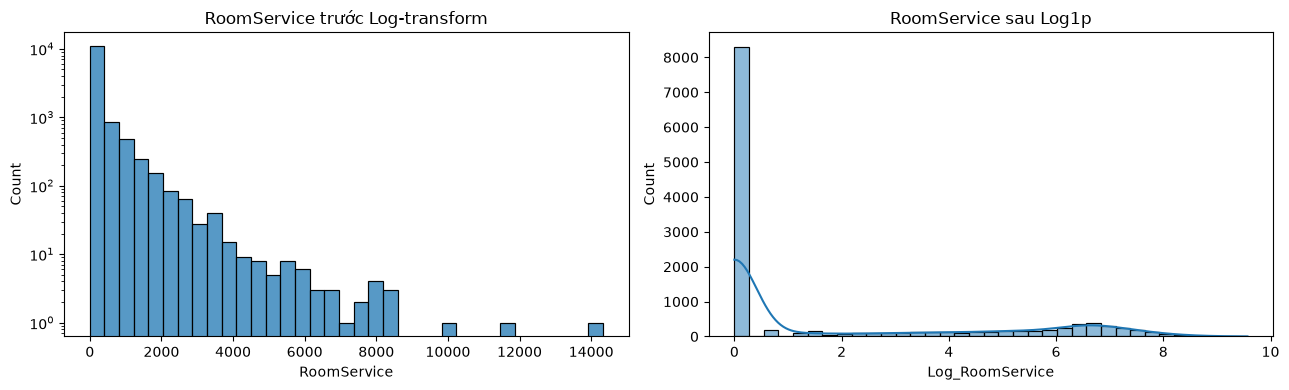

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(
    df_all["RoomService"].fillna(0),
    bins=35,
    ax=axes[0]
)
axes[0].set_yscale("log")
axes[0].set_title("RoomService trước Log-transform")

sns.histplot(
    df_all["Log_RoomService"].dropna(),
    bins=35,
    kde=True,
    ax=axes[1]
)
axes[1].set_title("RoomService sau Log1p")

plt.tight_layout()
plt.show()

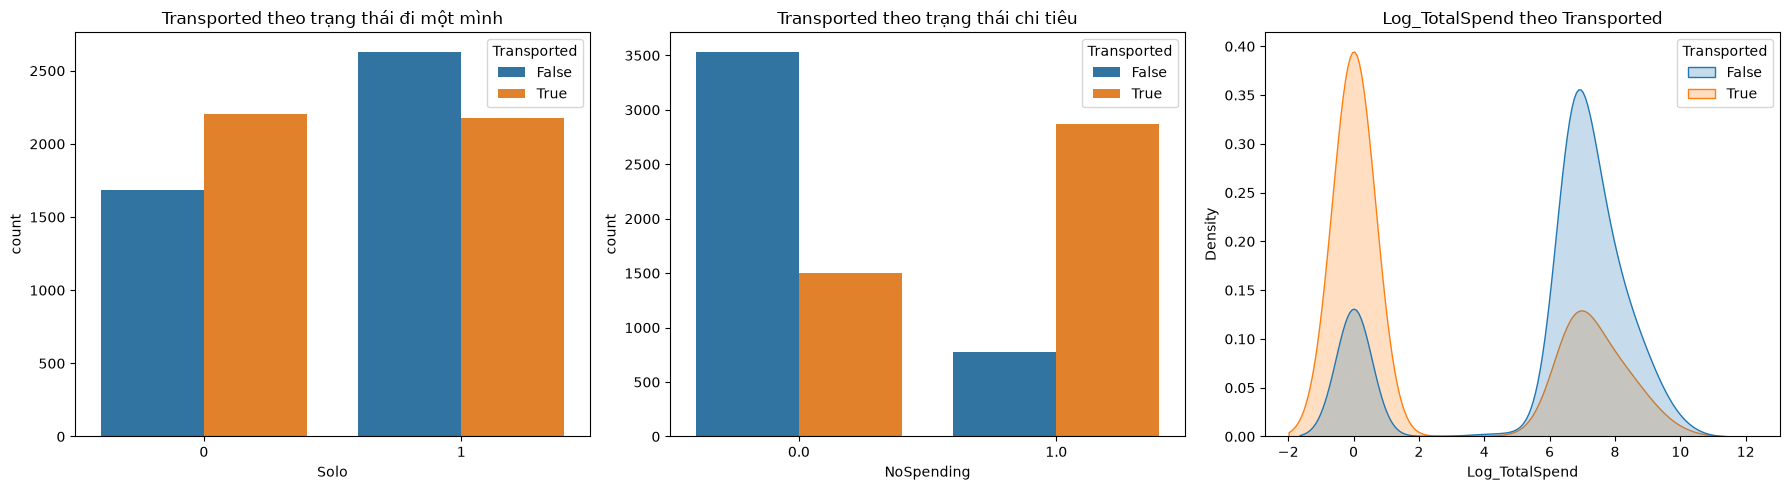

In [14]:
train_feature_view = df_all.iloc[:train_len].copy()
train_feature_view["Transported"] = y_train.astype(bool).values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(
    data=train_feature_view,
    x="Solo",
    hue="Transported",
    ax=axes[0]
)
axes[0].set_title("Transported theo trạng thái đi một mình")

sns.countplot(
    data=train_feature_view,
    x="NoSpending",
    hue="Transported",
    ax=axes[1]
)
axes[1].set_title("Transported theo trạng thái chi tiêu")

sns.kdeplot(
    data=train_feature_view,
    x="Log_TotalSpend",
    hue="Transported",
    fill=True,
    common_norm=False,
    ax=axes[2]
)
axes[2].set_title("Log_TotalSpend theo Transported")

plt.tight_layout()
plt.show()


# Bước 3: Xử lý dữ liệu thiếu bằng Smart Imputation

Việc điền missing được thực hiện theo thứ tự từ logic cụ thể đến phương
pháp thống kê tổng quát.

### 1. Logic `CryoSleep` và chi tiêu

- Nếu đã phát sinh chi tiêu, hành khách không thể đang ngủ đông.
- Nếu `CryoSleep=True`, khoản chi tiêu bị thiếu được điền bằng 0.

### 2. Logic nhóm hành khách

Các thành viên cùng nhóm thường có chung `HomePlanet`, `Destination`,
`CabinDeck` và `CabinSide`. Missing được ưu tiên điền bằng mode trong nhóm.

### 3. Median theo nhóm nhỏ

- `Age`: median của cùng `HomePlanet` và `CabinDeck`.
- `CabinNum`: median của cùng `CabinDeck`.
- Chi tiêu còn thiếu: median theo trạng thái `CryoSleep`.

### 4. Global fallback

Các giá trị còn thiếu sau những bước trên được điền bằng median hoặc mode
toàn cục.


In [15]:
df_imputed = df_all.copy()
missing_before = df_imputed.isna().sum()

# Nếu có chi tiêu quan sát được, CryoSleep được suy luận là False.
observed_spend = df_imputed[SPENDING_COLS].fillna(0).sum(axis=1)

df_imputed.loc[
    df_imputed["CryoSleep"].isna() & observed_spend.gt(0),
    "CryoSleep"
] = False

# Nếu CryoSleep=True, chi tiêu bị thiếu được điền bằng 0.
cryo_mask = df_imputed["CryoSleep"].eq(True)

for column in SPENDING_COLS:
    df_imputed.loc[cryo_mask, column] = (
        df_imputed.loc[cryo_mask, column].fillna(0)
    )

print("Missing CryoSleep còn lại:", df_imputed["CryoSleep"].isna().sum())

Missing CryoSleep còn lại: 136


In [16]:
def fill_with_group_mode(dataframe, group_column, value_column):
    group_mode = dataframe.groupby(group_column)[value_column].agg(
        lambda values: (
            values.mode().iloc[0]
            if not values.mode().empty
            else np.nan
        )
    )

    dataframe[value_column] = dataframe[value_column].fillna(
        dataframe[group_column].map(group_mode)
    )

group_fill_columns = [
    "HomePlanet",
    "Destination",
    "CabinDeck",
    "CabinSide"
]

for column in group_fill_columns:
    fill_with_group_mode(
        df_imputed,
        group_column="Group",
        value_column=column
    )

group_fill_audit = pd.DataFrame({
    "Column": group_fill_columns,
    "Missing after group fill": [
        df_imputed[column].isna().sum()
        for column in group_fill_columns
    ]
})

display(group_fill_audit)

,Column,Missing after group fill
0,HomePlanet,157
1,Destination,154
2,CabinDeck,162
3,CabinSide,162


In [17]:
# Điền Age theo HomePlanet và CabinDeck.
df_imputed["Age"] = (
    df_imputed.groupby(
        ["HomePlanet", "CabinDeck"],
        dropna=False
    )["Age"]
    .transform(
        lambda values: values.fillna(values.median())
    )
)

# Điền CabinNum theo từng CabinDeck.
df_imputed["CabinNum"] = (
    df_imputed.groupby(
        "CabinDeck",
        dropna=False
    )["CabinNum"]
    .transform(
        lambda values: values.fillna(values.median())
    )
)

# Điền chi tiêu còn thiếu bằng median theo CryoSleep.
for column in SPENDING_COLS:
    df_imputed[column] = (
        df_imputed.groupby(
            "CryoSleep",
            dropna=False
        )[column]
        .transform(
            lambda values: values.fillna(values.median())
        )
    )

In [18]:
# Fallback cho categorical.
categorical_fallback = [
    "HomePlanet",
    "Destination",
    "CryoSleep",
    "VIP",
    "CabinDeck",
    "CabinSide"
]

for column in categorical_fallback:
    mode_value = df_imputed[column].mode(dropna=True).iloc[0]
    df_imputed[column] = df_imputed[column].fillna(mode_value)

# Fallback cho numeric.
numeric_fallback = [
    "Age",
    "CabinNum",
    "PassengerNo",
    "GroupSize",
    "FamilySize"
] + SPENDING_COLS

for column in numeric_fallback:
    df_imputed[column] = df_imputed[column].fillna(
        df_imputed[column].median()
    )

# Tính lại các feature phụ thuộc vào dữ liệu vừa được điền.
df_imputed["TotalSpend"] = df_imputed[SPENDING_COLS].sum(axis=1)
df_imputed["NoSpending"] = (
    df_imputed["TotalSpend"].eq(0).astype(int)
)
df_imputed["ServiceCount"] = (
    df_imputed[SPENDING_COLS].gt(0).sum(axis=1)
)

df_imputed["BasicSpend"] = (
    df_imputed["RoomService"]
    + df_imputed["FoodCourt"]
    + df_imputed["ShoppingMall"]
)

df_imputed["LuxurySpend"] = (
    df_imputed["Spa"]
    + df_imputed["VRDeck"]
)

df_imputed["SpendingPerService"] = np.where(
    df_imputed["ServiceCount"].gt(0),
    df_imputed["TotalSpend"] / df_imputed["ServiceCount"],
    0
)

df_imputed["AgeGroup"] = pd.cut(
    df_imputed["Age"],
    bins=[-1, 12, 18, 30, 50, 65, np.inf],
    labels=[
        "Child",
        "Teenager",
        "YoungAdult",
        "Adult",
        "MiddleAge",
        "Senior"
    ]
)

for column in (
    SPENDING_COLS
    + ["TotalSpend", "BasicSpend", "LuxurySpend"]
):
    df_imputed[f"Log_{column}"] = np.log1p(
        df_imputed[column]
    )

missing_after = df_imputed.isna().sum()

imputation_audit = pd.DataFrame({
    "Missing before": missing_before,
    "Missing after": missing_after,
    "Values filled": missing_before - missing_after
})

display(
    imputation_audit.loc[
        imputation_audit["Values filled"].gt(0)
    ].sort_values("Values filled", ascending=False)
)

print(
    "Tổng missing còn lại:",
    int(df_imputed.isna().sum().sum())
)

,Missing before,Missing after,Values filled
CryoSleep,310,0,310
Log_ShoppingMall,306,0,306
ShoppingMall,306,0,306
CabinSide,299,0,299
CabinNum,299,0,299
CabinDeck,299,0,299
VIP,296,0,296
Log_FoodCourt,289,0,289
FoodCourt,289,0,289
HomePlanet,288,0,288


Tổng missing còn lại: 1480



# Bước 4: Thiết lập Pipeline tiền xử lý

Các cột được chia thành ba nhóm:

1. **Numerical:** median fallback và `StandardScaler`.
2. **Categorical:** mode fallback và `OneHotEncoder`.
3. **Binary:** mode fallback, giữ dưới dạng 0/1.

Mặc dù Smart Imputation đã xử lý missing, `SimpleImputer` vẫn được đặt
trong pipeline như một lớp bảo vệ khi notebook chạy trên phiên bản dữ liệu
khác.


In [19]:
LOG_SPENDING_COLS = [
    f"Log_{column}"
    for column in SPENDING_COLS
]

numeric_features = [
    "Age",
    "PassengerNo",
    "GroupSize",
    "FamilySize",
    "CabinNum",
    "ServiceCount",
    "SpendingPerService",
    "Log_TotalSpend",
    "Log_BasicSpend",
    "Log_LuxurySpend",
    *LOG_SPENDING_COLS
]

categorical_features = [
    "HomePlanet",
    "Destination",
    "CabinDeck",
    "CabinSide",
    "CabinRegion",
    "AgeGroup"
]

binary_features = [
    "CryoSleep",
    "VIP",
    "NoSpending",
    "Solo"
]

for column in ["CryoSleep", "VIP"]:
    df_imputed[column] = df_imputed[column].astype(int)

selected_features = (
    numeric_features
    + categorical_features
    + binary_features
)

df_model = df_imputed[selected_features].copy()

X_train_raw = df_model.iloc[:train_len].reset_index(drop=True)
X_test_raw = df_model.iloc[train_len:].reset_index(drop=True)

feature_groups = pd.DataFrame({
    "Group": ["Numerical", "Categorical", "Binary"],
    "Count": [
        len(numeric_features),
        len(categorical_features),
        len(binary_features)
    ],
    "Features": [
        ", ".join(numeric_features),
        ", ".join(categorical_features),
        ", ".join(binary_features)
    ]
})

display(feature_groups)

print("X_train_raw:", X_train_raw.shape)
print("X_test_raw :", X_test_raw.shape)
display(X_train_raw.head())

,Group,Count,Features
0,Numerical,15,"Age, PassengerNo, GroupSize, FamilySize, Cabin..."
1,Categorical,6,"HomePlanet, Destination, CabinDeck, CabinSide,..."
2,Binary,4,"CryoSleep, VIP, NoSpending, Solo"


X_train_raw: (8693, 25)
X_test_raw : (4277, 25)


,Age,PassengerNo,GroupSize,FamilySize,CabinNum,ServiceCount,SpendingPerService,Log_TotalSpend,Log_BasicSpend,Log_LuxurySpend,Log_RoomService,Log_FoodCourt,Log_ShoppingMall,Log_Spa,Log_VRDeck,HomePlanet,Destination,CabinDeck,CabinSide,CabinRegion,AgeGroup,CryoSleep,VIP,NoSpending,Solo
0,39.0000,1,1,1.0000,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,Europa,TRAPPIST-1e,B,P,R1,Adult,0,0,1,1
1,24.0000,1,1,1.0000,0.0000,5,147.2000,6.6026,4.9698,6.3869,4.7005,2.3026,3.2581,6.3099,3.8067,Earth,TRAPPIST-1e,F,S,R1,YoungAdult,0,0,0,1
2,58.0000,1,2,2.0000,0.0000,4,"2,595.7500",9.2480,8.1942,8.8195,3.7842,8.1823,0.0000,8.8122,3.9120,Europa,TRAPPIST-1e,A,S,R1,MiddleAge,0,1,0,0
3,33.0000,2,2,2.0000,0.0000,4,"1,294.0000",8.5520,7.4116,8.1671,0.0000,7.1577,5.9189,8.1107,5.2679,Europa,TRAPPIST-1e,A,S,R1,Adult,0,0,0,0
4,16.0000,1,1,1.0000,1.0000,5,218.2000,6.9958,6.2634,6.3421,5.7170,4.2627,5.0239,6.3386,1.0986,Earth,TRAPPIST-1e,F,S,R1,Teenager,0,0,0,1


In [20]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

try:
    one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        one_hot_encoder
    )
])

binary_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    )
])

preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    ),
    (
        "binary",
        binary_pipeline,
        binary_features
    )
])

preview_preprocessor = clone(preprocessor)
preview_matrix = preview_preprocessor.fit_transform(
    X_train_raw.head(1000)
)

print("Số cột trước preprocessing:", X_train_raw.shape[1])
print("Số cột sau preprocessing :", preview_matrix.shape[1])

Số cột trước preprocessing: 25
Số cột sau preprocessing : 41



# Khởi tạo các mô hình benchmark

Bài làm benchmark các mô hình theo đúng ba nhóm chính của Ensemble Learning:

- **Baseline:** Logistic Regression, Decision Tree.
- **Bagging:** Random Forest.
- **Boosting:** Gradient Boosting, LightGBM, XGBoost, CatBoost.

Ba thư viện Boosting ngoài `scikit-learn` được dùng vì chúng thường phù hợp
với dữ liệu bảng. Cell tiếp theo có thể tự cài nếu môi trường còn thiếu.


In [21]:
%pip install -q lightgbm xgboost catboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
AUTO_INSTALL_MISSING_PACKAGES = False

required_packages = {
    "lightgbm": "lightgbm",
    "xgboost": "xgboost",
    "catboost": "catboost"
}

missing_packages = [
    package_name
    for module_name, package_name in required_packages.items()
    if importlib.util.find_spec(module_name) is None
]

if missing_packages and AUTO_INSTALL_MISSING_PACKAGES:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            *missing_packages
        ]
    )

if missing_packages and not AUTO_INSTALL_MISSING_PACKAGES:
    raise ImportError(
        "Thiếu các thư viện: "
        + ", ".join(missing_packages)
        + ". Hãy đổi AUTO_INSTALL_MISSING_PACKAGES=True "
          "và chạy lại cell này, hoặc cài bằng: "
          "%pip install lightgbm xgboost catboost"
    )

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

print("Đã sẵn sàng LightGBM, XGBoost và CatBoost.")

Đã sẵn sàng LightGBM, XGBoost và CatBoost.


In [23]:
initial_models = {
    "Logistic Regression": {
        "Technique": "Baseline",
        "Model": LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_STATE
        )
    },
    "Decision Tree": {
        "Technique": "Baseline",
        "Model": DecisionTreeClassifier(
            max_depth=6,
            min_samples_leaf=10,
            random_state=RANDOM_STATE
        )
    },
    "Random Forest": {
        "Technique": "Bagging",
        "Model": RandomForestClassifier(
            n_estimators=300,
            max_depth=10,
            min_samples_leaf=2,
            max_features="sqrt",
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    },
    "Gradient Boosting": {
        "Technique": "Boosting",
        "Model": GradientBoostingClassifier(
            n_estimators=220,
            learning_rate=0.04,
            max_depth=3,
            subsample=0.85,
            random_state=RANDOM_STATE
        )
    },
    "LightGBM": {
        "Technique": "Boosting",
        "Model": LGBMClassifier(
            n_estimators=350,
            learning_rate=0.03,
            max_depth=6,
            num_leaves=31,
            subsample=0.85,
            colsample_bytree=0.85,
            random_state=RANDOM_STATE,
            verbose=-1,
            n_jobs=-1
        )
    },
    "XGBoost": {
        "Technique": "Boosting",
        "Model": XGBClassifier(
            n_estimators=350,
            learning_rate=0.03,
            max_depth=5,
            subsample=0.85,
            colsample_bytree=0.85,
            random_state=RANDOM_STATE,
            eval_metric="logloss",
            n_jobs=-1
        )
    },
    "CatBoost": {
        "Technique": "Boosting",
        "Model": CatBoostClassifier(
            iterations=350,
            learning_rate=0.03,
            depth=6,
            l2_leaf_reg=5,
            random_seed=RANDOM_STATE,
            verbose=False,
            allow_writing_files=False,
            thread_count=-1
        )
    }
}

print("Các mô hình benchmark ban đầu:")
for model_name, model_info in initial_models.items():
    print(f"- {model_info['Technique']}: {model_name}")

Các mô hình benchmark ban đầu:
- Baseline: Logistic Regression
- Baseline: Decision Tree
- Bagging: Random Forest
- Boosting: Gradient Boosting
- Boosting: LightGBM
- Boosting: XGBoost
- Boosting: CatBoost



# Huấn luyện và đánh giá bằng Stratified 5-Fold Cross-Validation

Mọi mô hình sử dụng cùng:

- Một preprocessing pipeline.
- Một bộ chia fold.
- Các metric Accuracy, F1-score và ROC-AUC.

Accuracy là metric chính vì Kaggle chấm theo accuracy. F1-score và
ROC-AUC giúp kiểm tra mô hình không chỉ cải thiện bằng cách thiên lệch về
một lớp.


In [24]:
cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

initial_benchmark_rows = []

for model_name, model_info in initial_models.items():
    print(f"Đang đánh giá: {model_name}")

    model_pipeline = Pipeline([
        (
            "preprocessor",
            clone(preprocessor)
        ),
        (
            "classifier",
            clone(model_info["Model"])
        )
    ])

    start_time = time.time()

    cv_result = cross_validate(
        model_pipeline,
        X_train_raw,
        y_train,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "f1": "f1",
            "roc_auc": "roc_auc"
        },
        n_jobs=1,
        return_train_score=False,
        error_score="raise"
    )

    initial_benchmark_rows.append({
        "Stage": "Initial benchmark",
        "Technique": model_info["Technique"],
        "Model": model_name,
        "CV Accuracy": cv_result["test_accuracy"].mean(),
        "Accuracy Std": cv_result["test_accuracy"].std(),
        "CV F1": cv_result["test_f1"].mean(),
        "CV ROC-AUC": cv_result["test_roc_auc"].mean(),
        "Mean Fit Time (s)": cv_result["fit_time"].mean(),
        "Total Time (s)": time.time() - start_time
    })

initial_benchmark_df = (
    pd.DataFrame(initial_benchmark_rows)
    .sort_values(
        ["CV Accuracy", "CV F1"],
        ascending=False
    )
    .reset_index(drop=True)
)

display(initial_benchmark_df)

Đang đánh giá: Logistic Regression
Đang đánh giá: Decision Tree
Đang đánh giá: Random Forest
Đang đánh giá: Gradient Boosting
Đang đánh giá: LightGBM
Đang đánh giá: XGBoost
Đang đánh giá: CatBoost


,Stage,Technique,Model,CV Accuracy,Accuracy Std,CV F1,CV ROC-AUC,Mean Fit Time (s),Total Time (s)
0,Initial benchmark,Boosting,XGBoost,0.8147,0.0074,0.8166,0.9050,0.7891,4.2384
1,Initial benchmark,Boosting,CatBoost,0.8143,0.0065,0.8196,0.9052,2.3540,12.0350
2,Initial benchmark,Boosting,LightGBM,0.8095,0.0052,0.8115,0.9030,0.9409,5.0813
3,Initial benchmark,Boosting,Gradient Boosting,0.8052,0.0079,0.8120,0.8995,5.9833,30.2685
4,Initial benchmark,Bagging,Random Forest,0.8028,0.0088,0.8057,0.8952,1.1909,7.4667
5,Initial benchmark,Baseline,Decision Tree,0.7894,0.0101,0.7897,0.8777,0.1156,0.8333
6,Initial benchmark,Baseline,Logistic Regression,0.7837,0.0063,0.7900,0.8644,0.1499,0.9905


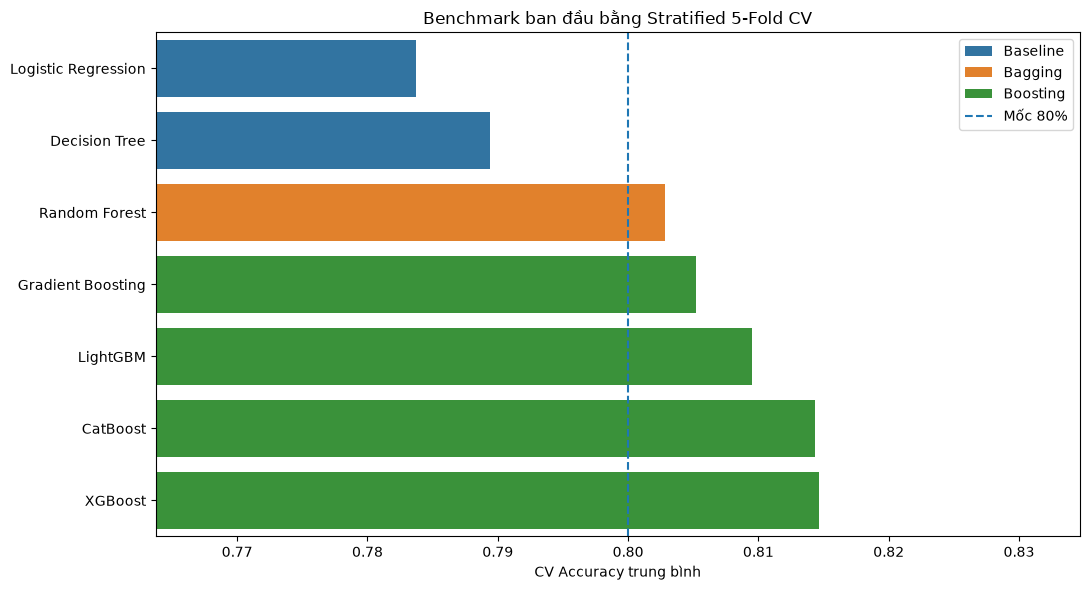

In [25]:
plot_df = initial_benchmark_df.sort_values("CV Accuracy")

plt.figure(figsize=(11, 6))

sns.barplot(
    data=plot_df,
    x="CV Accuracy",
    y="Model",
    hue="Technique",
    dodge=False
)

plt.axvline(
    0.80,
    linestyle="--",
    label="Mốc 80%"
)

plt.xlim(
    max(0.70, plot_df["CV Accuracy"].min() - 0.02),
    min(1.00, plot_df["CV Accuracy"].max() + 0.02)
)

plt.title("Benchmark ban đầu bằng Stratified 5-Fold CV")
plt.xlabel("CV Accuracy trung bình")
plt.ylabel("")
plt.legend()

plt.tight_layout()
plt.show()


# Bước 5: Tinh chỉnh nhẹ ba mô hình Boosting mạnh

Thay vì gọi một cấu hình cố định là “tối ưu”, bài làm kiểm thử hai cấu hình
ứng viên cho từng mô hình:

- LightGBM
- XGBoost
- CatBoost

Tuning sử dụng Stratified 3-Fold CV để thời gian chạy hợp lý. Sau đó, cấu
hình tốt nhất của mỗi mô hình được đánh giá lại bằng 5-Fold CV cùng Voting
và Stacking.


In [26]:
tuning_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

tuning_candidates = {
    "LightGBM": [
        {
            "n_estimators": 450,
            "learning_rate": 0.025,
            "max_depth": 6,
            "num_leaves": 31,
            "subsample": 0.85,
            "colsample_bytree": 0.85
        },
        {
            "n_estimators": 600,
            "learning_rate": 0.018,
            "max_depth": 7,
            "num_leaves": 40,
            "subsample": 0.80,
            "colsample_bytree": 0.80
        }
    ],
    "XGBoost": [
        {
            "n_estimators": 450,
            "learning_rate": 0.025,
            "max_depth": 5,
            "subsample": 0.85,
            "colsample_bytree": 0.85,
            "min_child_weight": 2
        },
        {
            "n_estimators": 600,
            "learning_rate": 0.018,
            "max_depth": 6,
            "subsample": 0.80,
            "colsample_bytree": 0.80,
            "min_child_weight": 3
        }
    ],
    "CatBoost": [
        {
            "iterations": 450,
            "learning_rate": 0.025,
            "depth": 6,
            "l2_leaf_reg": 5
        },
        {
            "iterations": 600,
            "learning_rate": 0.018,
            "depth": 7,
            "l2_leaf_reg": 7
        }
    ]
}

def build_boosting_model(model_name, parameters):
    if model_name == "LightGBM":
        return LGBMClassifier(
            **parameters,
            random_state=RANDOM_STATE,
            verbose=-1,
            n_jobs=-1
        )

    if model_name == "XGBoost":
        return XGBClassifier(
            **parameters,
            random_state=RANDOM_STATE,
            eval_metric="logloss",
            n_jobs=-1
        )

    if model_name == "CatBoost":
        return CatBoostClassifier(
            **parameters,
            random_seed=RANDOM_STATE,
            verbose=False,
            allow_writing_files=False,
            thread_count=-1
        )

    raise ValueError(f"Không hỗ trợ model: {model_name}")

In [27]:
tuning_rows = []
best_parameters = {}
best_tuning_scores = {}

for model_name, candidate_list in tuning_candidates.items():
    print(f"\nTinh chỉnh {model_name}")

    model_candidate_rows = []

    for candidate_index, parameters in enumerate(
        candidate_list,
        start=1
    ):
        candidate_model = build_boosting_model(
            model_name,
            parameters
        )

        candidate_pipeline = Pipeline([
            (
                "preprocessor",
                clone(preprocessor)
            ),
            (
                "classifier",
                candidate_model
            )
        ])

        candidate_cv = cross_validate(
            candidate_pipeline,
            X_train_raw,
            y_train,
            cv=tuning_cv,
            scoring={
                "accuracy": "accuracy",
                "f1": "f1"
            },
            n_jobs=1,
            return_train_score=False,
            error_score="raise"
        )

        row = {
            "Model": model_name,
            "Candidate": candidate_index,
            "Parameters": parameters,
            "CV Accuracy": candidate_cv["test_accuracy"].mean(),
            "Accuracy Std": candidate_cv["test_accuracy"].std(),
            "CV F1": candidate_cv["test_f1"].mean()
        }

        tuning_rows.append(row)
        model_candidate_rows.append(row)

        print(
            f"  Candidate {candidate_index}: "
            f"Accuracy={row['CV Accuracy']:.4f}, "
            f"F1={row['CV F1']:.4f}"
        )

    best_row = sorted(
        model_candidate_rows,
        key=lambda row: (
            row["CV Accuracy"],
            row["CV F1"],
            -row["Accuracy Std"]
        ),
        reverse=True
    )[0]

    best_parameters[model_name] = best_row["Parameters"]
    best_tuning_scores[model_name] = best_row["CV Accuracy"]

tuning_results_df = (
    pd.DataFrame(tuning_rows)
    .sort_values(
        ["Model", "CV Accuracy"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

display(tuning_results_df)


Tinh chỉnh LightGBM
  Candidate 1: Accuracy=0.8082, F1=0.8091
  Candidate 2: Accuracy=0.8086, F1=0.8087

Tinh chỉnh XGBoost
  Candidate 1: Accuracy=0.8096, F1=0.8101
  Candidate 2: Accuracy=0.8063, F1=0.8060

Tinh chỉnh CatBoost
  Candidate 1: Accuracy=0.8144, F1=0.8189
  Candidate 2: Accuracy=0.8140, F1=0.8179


,Model,Candidate,Parameters,CV Accuracy,Accuracy Std,CV F1
0,CatBoost,1,"{'iterations': 450, 'learning_rate': 0.025, 'd...",0.8144,0.0049,0.8189
1,CatBoost,2,"{'iterations': 600, 'learning_rate': 0.018, 'd...",0.8140,0.0044,0.8179
2,LightGBM,2,"{'n_estimators': 600, 'learning_rate': 0.018, ...",0.8086,0.0046,0.8087
3,LightGBM,1,"{'n_estimators': 450, 'learning_rate': 0.025, ...",0.8082,0.0051,0.8091
4,XGBoost,1,"{'n_estimators': 450, 'learning_rate': 0.025, ...",0.8096,0.0052,0.8101
5,XGBoost,2,"{'n_estimators': 600, 'learning_rate': 0.018, ...",0.8063,0.0057,0.8060


In [28]:
tuned_lgb = build_boosting_model(
    "LightGBM",
    best_parameters["LightGBM"]
)

tuned_xgb = build_boosting_model(
    "XGBoost",
    best_parameters["XGBoost"]
)

tuned_cat = build_boosting_model(
    "CatBoost",
    best_parameters["CatBoost"]
)

selected_configurations = pd.DataFrame({
    "Model": ["LightGBM", "XGBoost", "CatBoost"],
    "Selected parameters": [
        best_parameters["LightGBM"],
        best_parameters["XGBoost"],
        best_parameters["CatBoost"]
    ],
    "Tuning CV Accuracy": [
        best_tuning_scores["LightGBM"],
        best_tuning_scores["XGBoost"],
        best_tuning_scores["CatBoost"]
    ]
})

display(selected_configurations)

,Model,Selected parameters,Tuning CV Accuracy
0,LightGBM,"{'n_estimators': 600, 'learning_rate': 0.018, ...",0.8086
1,XGBoost,"{'n_estimators': 450, 'learning_rate': 0.025, ...",0.8096
2,CatBoost,"{'iterations': 450, 'learning_rate': 0.025, 'd...",0.8144



# 1. Weighted Soft Voting Ensemble

Soft Voting kết hợp xác suất dự đoán của ba mô hình đã tinh chỉnh.

Khác với Voting trung bình đều, bài làm sử dụng Accuracy từ tuning CV làm
trọng số. Mô hình có kết quả ổn định hơn đóng góp nhiều hơn một chút vào
xác suất cuối.


In [29]:
voting_weights = [
    best_tuning_scores["LightGBM"],
    best_tuning_scores["XGBoost"],
    best_tuning_scores["CatBoost"]
]

weighted_voting_model = VotingClassifier(
    estimators=[
        ("lgb", tuned_lgb),
        ("xgb", tuned_xgb),
        ("cat", tuned_cat)
    ],
    voting="soft",
    weights=voting_weights,
    n_jobs=-1
)

print("Voting weights:", voting_weights)

Voting weights: [np.float64(0.8085822343525214), np.float64(0.8096173913361109), np.float64(0.8144477930613513)]



# 2. Stacking Ensemble

Stacking tạo dự đoán out-of-fold từ ba base learner, sau đó dùng Logistic
Regression làm meta-learner.

`passthrough=True` cho phép meta-learner nhìn cả dự đoán của các mô hình
thành phần lẫn các đặc trưng đã preprocessing. Đây là điểm khác với
Stacking chỉ dùng ba xác suất đầu ra.


In [30]:
stacking_model = StackingClassifier(
    estimators=[
        ("lgb", tuned_lgb),
        ("xgb", tuned_xgb),
        ("cat", tuned_cat)
    ],
    final_estimator=LogisticRegression(
        C=0.5,
        max_iter=2500,
        random_state=RANDOM_STATE
    ),
    stack_method="predict_proba",
    cv=3,
    passthrough=True,
    n_jobs=-1
)


## Đánh giá lại các mô hình mạnh bằng cùng 5-Fold CV

Ba boosting model đã tinh chỉnh, Weighted Voting và Stacking được đánh
giá lại bằng cùng một bộ 5 fold. Bảng này mới được dùng để chọn mô hình
cuối.


In [ ]:
final_candidate_models = {
    "LightGBM Tuned": {
        "Technique": "Boosting",
        "Model": tuned_lgb
    },
    "XGBoost Tuned": {
        "Technique": "Boosting",
        "Model": tuned_xgb
    },
    "CatBoost Tuned": {
        "Technique": "Boosting",
        "Model": tuned_cat
    },
    "Weighted Soft Voting": {
        "Technique": "Ensemble",
        "Model": weighted_voting_model
    },
    "Stacking": {
        "Technique": "Ensemble",
        "Model": stacking_model
    }
}

final_comparison_rows = []

for model_name, model_info in final_candidate_models.items():
    print(f"Đang đánh giá: {model_name}")

    candidate_pipeline = Pipeline([
        (
            "preprocessor",
            clone(preprocessor)
        ),
        (
            "classifier",
            clone(model_info["Model"])
        )
    ])

    start_time = time.time()

    candidate_result = cross_validate(
        candidate_pipeline,
        X_train_raw,
        y_train,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "f1": "f1",
            "roc_auc": "roc_auc"
        },
        n_jobs=1,
        return_train_score=False,
        error_score="raise"
    )

    final_comparison_rows.append({
        "Stage": "Refined models",
        "Technique": model_info["Technique"],
        "Model": model_name,
        "CV Accuracy": candidate_result["test_accuracy"].mean(),
        "Accuracy Std": candidate_result["test_accuracy"].std(),
        "CV F1": candidate_result["test_f1"].mean(),
        "CV ROC-AUC": candidate_result["test_roc_auc"].mean(),
        "Mean Fit Time (s)": candidate_result["fit_time"].mean(),
        "Total Time (s)": time.time() - start_time
    })

final_comparison_df = (
    pd.DataFrame(final_comparison_rows)
    .sort_values(
        ["CV Accuracy", "CV F1", "Accuracy Std"],
        ascending=[False, False, True]
    )
    .reset_index(drop=True)
)

display(final_comparison_df)

Đang đánh giá: LightGBM Tuned
Đang đánh giá: XGBoost Tuned
Đang đánh giá: CatBoost Tuned
Đang đánh giá: Weighted Soft Voting
Đang đánh giá: Stacking


In [ ]:
plt.figure(figsize=(11, 5))

sns.barplot(
    data=final_comparison_df.sort_values("CV Accuracy"),
    x="CV Accuracy",
    y="Model",
    hue="Technique",
    dodge=False
)

plt.axvline(
    0.80,
    linestyle="--",
    label="Mốc 80%"
)

plt.xlim(
    max(
        0.75,
        final_comparison_df["CV Accuracy"].min() - 0.015
    ),
    min(
        1.00,
        final_comparison_df["CV Accuracy"].max() + 0.015
    )
)

plt.title("So sánh các mô hình sau tinh chỉnh")
plt.xlabel("CV Accuracy trung bình")
plt.ylabel("")
plt.legend()

plt.tight_layout()
plt.show()


# Chọn mô hình Ensemble cuối

Đề bài yêu cầu thực hiện Ensemble Learning. Vì vậy, mô hình cuối được chọn
giữa:

- Weighted Soft Voting
- Stacking

Tiêu chí sắp xếp:

1. CV Accuracy cao hơn.
2. Nếu gần bằng nhau, ưu tiên F1-score cao hơn.
3. Nếu vẫn gần bằng nhau, ưu tiên độ lệch chuẩn thấp hơn.

Việc chọn chỉ dựa vào kết quả đã tính, không gán trước Stacking là mô hình
tốt nhất.


In [ ]:
ensemble_comparison_df = (
    final_comparison_df[
        final_comparison_df["Technique"] == "Ensemble"
    ]
    .sort_values(
        ["CV Accuracy", "CV F1", "Accuracy Std"],
        ascending=[False, False, True]
    )
    .reset_index(drop=True)
)

final_model_name = ensemble_comparison_df.loc[0, "Model"]
final_model = final_candidate_models[final_model_name]["Model"]

final_cv_accuracy = ensemble_comparison_df.loc[0, "CV Accuracy"]
final_cv_f1 = ensemble_comparison_df.loc[0, "CV F1"]
final_cv_std = ensemble_comparison_df.loc[0, "Accuracy Std"]

print("Mô hình Ensemble được chọn")
print("---------------------------")
print("Model       :", final_model_name)
print(f"CV Accuracy : {final_cv_accuracy:.4f}")
print(f"CV F1       : {final_cv_f1:.4f}")
print(f"Accuracy Std: {final_cv_std:.4f}")


# Bước 6: Huấn luyện mô hình cuối và tạo submission

Mô hình được fit lại trên toàn bộ tập train, sau đó dự đoán tập test.

`Transported` được chuyển về kiểu boolean để đúng định dạng cuộc thi.


In [ ]:
final_pipeline = Pipeline([
    (
        "preprocessor",
        clone(preprocessor)
    ),
    (
        "classifier",
        clone(final_model)
    )
])

print("Đang huấn luyện mô hình cuối...")
final_pipeline.fit(X_train_raw, y_train)

print("Đang dự đoán tập test...")
test_predictions = final_pipeline.predict(
    X_test_raw
).astype(bool)

submission_df = pd.DataFrame({
    "PassengerId": test_raw["PassengerId"],
    "Transported": test_predictions
})

submission_path = Path("submission.csv")
submission_df.to_csv(
    submission_path,
    index=False
)

display(submission_df.head())

print("Submission shape:", submission_df.shape)
print("Đã lưu tại:", submission_path.resolve())

In [ ]:
assert submission_df.shape[0] == test_raw.shape[0]
assert list(submission_df.columns) == [
    "PassengerId",
    "Transported"
]
assert submission_df.isna().sum().sum() == 0
assert submission_df["PassengerId"].equals(
    test_raw["PassengerId"]
)

if sample_submission is not None:
    assert submission_df.shape == sample_submission.shape
    assert list(submission_df.columns) == list(
        sample_submission.columns
    )

print("File submission hợp lệ.")


# Phân tích mức độ quan trọng của đặc trưng

Voting và Stacking không có một thuộc tính `feature_importances_` đơn giản.
Vì vậy, bài làm dùng **Permutation Importance** trên một holdout set:

- Xáo trộn từng feature đầu vào.
- Đo mức giảm accuracy.
- Feature làm accuracy giảm nhiều được xem là có ảnh hưởng lớn.

Cách này giải thích đúng mô hình cuối thay vì dùng importance của một mô
hình khác.


In [ ]:
X_train_part, X_valid, y_train_part, y_valid = train_test_split(
    X_train_raw,
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=RANDOM_STATE
)

explanation_pipeline = Pipeline([
    (
        "preprocessor",
        clone(preprocessor)
    ),
    (
        "classifier",
        clone(final_model)
    )
])

explanation_pipeline.fit(
    X_train_part,
    y_train_part
)

holdout_predictions = explanation_pipeline.predict(X_valid)
holdout_accuracy = accuracy_score(
    y_valid,
    holdout_predictions
)

print(f"Holdout Accuracy: {holdout_accuracy:.4f}")

importance_result = permutation_importance(
    explanation_pipeline,
    X_valid,
    y_valid,
    scoring="accuracy",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=1
)

importance_df = (
    pd.DataFrame({
        "Feature": X_valid.columns,
        "Importance Mean": importance_result.importances_mean,
        "Importance Std": importance_result.importances_std
    })
    .sort_values(
        "Importance Mean",
        ascending=False
    )
    .reset_index(drop=True)
)

display(importance_df.head(15))

In [ ]:
top_importance = (
    importance_df.head(15)
    .sort_values("Importance Mean")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_importance["Feature"],
    top_importance["Importance Mean"],
    xerr=top_importance["Importance Std"],
    capsize=3
)

plt.title(
    f"Top đặc trưng quan trọng — {final_model_name}"
)
plt.xlabel("Mức giảm Accuracy khi feature bị xáo trộn")
plt.ylabel("")

plt.tight_layout()
plt.show()


# Ma trận nhầm lẫn của mô hình cuối

Bài làm tạo dự đoán **Out-of-Fold** để mỗi hành khách được dự đoán bởi mô
hình chưa từng học từ chính mẫu đó.

Do Voting/Stacking có chi phí lớn, phần chẩn đoán sử dụng Stratified
3-Fold CV. Đây là đánh giá độc lập với việc fit mô hình cuối trên toàn bộ
train để tạo submission.


In [ ]:
diagnostic_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

diagnostic_pipeline = Pipeline([
    (
        "preprocessor",
        clone(preprocessor)
    ),
    (
        "classifier",
        clone(final_model)
    )
])

oof_predictions = cross_val_predict(
    diagnostic_pipeline,
    X_train_raw,
    y_train,
    cv=diagnostic_cv,
    method="predict",
    n_jobs=1
)

oof_accuracy = accuracy_score(
    y_train,
    oof_predictions
)

print(f"OOF Accuracy (3-Fold): {oof_accuracy:.4f}")
print()
print(
    classification_report(
        y_train,
        oof_predictions,
        target_names=[
            "Not Transported",
            "Transported"
        ]
    )
)

cm = confusion_matrix(
    y_train,
    oof_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Not Transported",
        "Transported"
    ]
)

disp.plot(
    values_format="d"
)

plt.title(
    f"Confusion Matrix OOF — {final_model_name}"
)
plt.grid(False)
plt.tight_layout()
plt.show()